# The Lotka-Volterra Model
### A classical predator-prey model

This model is one of great historical importance. But it should be noted that it is structurally unstable (we will visit this in a later chapter). 

In the mid-1920s Umberto D'Ancona performed a statistical analysis of the fish that were being sold at markets in Italy between 1910 and 1923. During the First World War (1914-1918), fishing was largely suspended in the upper Adraitic, and D'Ancona showed that this coincided with increases in the relative frequency of some species and decreases of relative frequencies of others. D'Ancona wanted to know why this had happened, so he asked his soon to be father-in-law Vito Volterra. Volterra had wrote down a simple pair of differential equations. Let $N(t)$ be the number (or density) of prey, and let $P(t)$ be the number (or density) of predators. The system that Volterra proposed was:

$$
\frac{dN}{dt} = rN - cNP \tag{2.1a}
$$

$$
\frac{dP}{dt} = bNP - mP \tag{2.1b}
$$

Where $r$ is the intrinsic rate of growth, $c$ is the predation rate, $b$ is the predator recruitment coefficient, and $m$ is the predator mortality rate.

We note that $r$ and $b$ are both to do with rates of growth. However, $b$ is defined as the predator recruitment coefficient, which is an important distinction to notice, since on the right hand side of equation $(2.1b)$ we have the terms $bNP$ which indicates that the predator growth rate is dependent on the number of prey, so if there were no prey, then the rate of growth will be negative, as the remaining term in $(2.1b)$ is negative since $m,P > 0$. This is an important dependency to notice as we see that for a fixed predator population, recruitment is proportional to prey abundance. This can also be seen in the right-hand side of $(2.1a)$ since the decrease of $\frac{dN}{dt}$ is dependent on how many of the prey are eaten by the predators, which shows that prey losses through predation proportional to the product $NP$.

This is what makes the predator-prey system defined in the Lotka-Volterra model interactive, and not just 2 differential equations. However, this leaves me with more questions, what if there are more than one predator who seeks the prey(competition, from outside of the predators, and internally within the predators too)? Are the prey defined here predators to another animal? (and similarly, are the predators in this model prey to something else?)(food chains). I can see where this model breaks down in the real world, which is a deeply rich interacting system of many parts where tiny influences can have a massive change elsewhere. This questions give me a hunger to go further into mathematical ecology, to explore the fascinating and complex system that we live in.

Moving on from this, I will implement this model using code, so we can get a visual representation of the interaction between predators and prey.

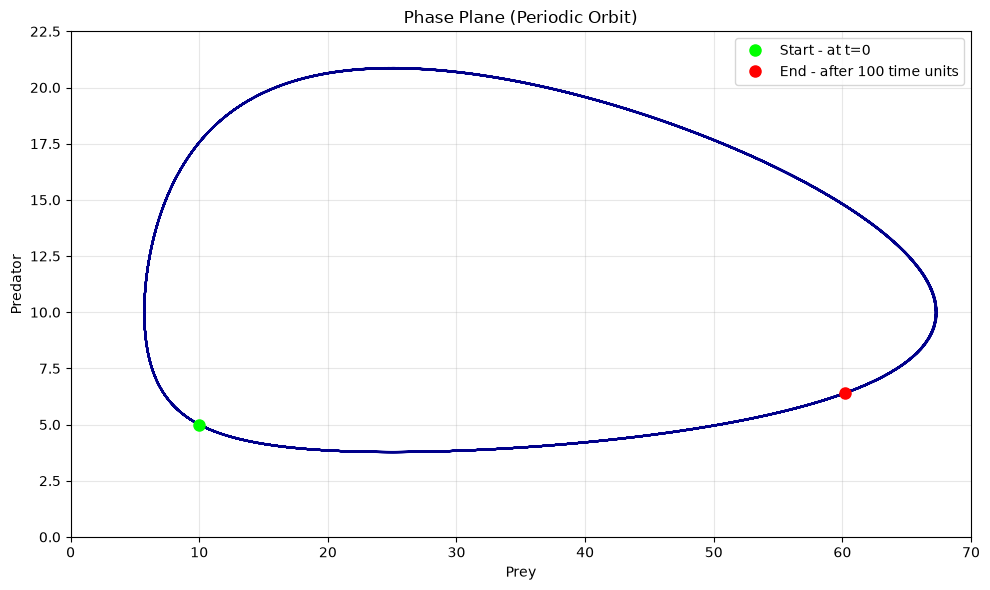

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Lotka-Volterra equations
def LV(y, t, r, c, b, m):
    """
    Lotka-Volterra predator-prey model.
    
    Parameters:
    y = [prey, predator]
    t = time
    r = prey intrinsic rate of growth
    c = predation rate (prey lost per predator per unit time)
    b = predator recruitment coefficient
    m = predator mortality rate
    
    Returns:
    [dprey/dt, dpredator/dt]
    """
    prey, pred = y
    dprey = r * prey - c * prey * pred
    dpred = b * prey * pred - m * pred
    return [dprey, dpred]


# parameters 
r = 1.0      # prey growth rate
c = 0.1      # predation rate
b = 0.02     # predator recruitment coefficient
m = 0.5      # predator death rate

# initial conditions
prey0 = 10   # starting prey population
pred0 = 5    # starting predator population
y0 = [prey0, pred0]

# time points
t = np.linspace(0, 100, 1000)

# solve the system
sol = odeint(LV, y0, t, args=(r, c, b, m))
prey_sol = sol[:, 0]
pred_sol = sol[:, 1]


# phase plane
plt.figure(figsize=(10,6))
plt.plot(prey_sol, pred_sol, color='darkblue', linewidth=1.5)
plt.plot(prey_sol[0], pred_sol[0], 'o', color='lime', markersize=8, label='Start - at t=0')
plt.plot(prey_sol[-1], pred_sol[-1], 'ro', markersize=8, label='End - after 100 time units')
plt.xlabel('Prey')
plt.ylabel('Predator')
plt.xlim(0,70)
plt.ylim(0,22.5)
plt.title('Phase Plane (Periodic Orbit)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

With the code, we have produced a phase plane diagram that gives us a link between the number of predators given the number of prey, for the defined parameters r, c, b, m and initial population numbers for the predators and prey. On this plot, the starting point is given by the green dot at t=0, after 100 time units, we see that the populations have changed for the 2 animals, denoted by the red dot. The numerical trajectory appears to follow a periodic orbit, meaning if this system were isolated from external perturbations, this cycle would continue to follow the same path over and over, although the plot does not prove periodicity.

Now begs the question, how is the population following this curve? Clockwise? Counter-clockwise? We will discover tools later on which will give us a mathematical answer, but we can use intuition to answer this question. Let us assume the flow is clockwise, on the lower section, predator numbers are low, prey growth therefore exceeds losses to predation, so the number of prey are increasing. However, following the orbit clockwise at this point suggests a decrease, a contradiction. Thus this assumption fails the reality check. Now, let us assume that the flow is counter-clockwise. We see that while the population of predators is low, the population of the prey is increasing. Then, while the population of prey increases, we start to see the population of the predators increase. So far, this makes sense, there are less predators, thus meaning an increase in the population of the prey since they are not being killed by as many predators, so it follows that there will be a greater number of prey that can reproduce, thus leading to an increasing population of prey. Now, when prey nears its maximum, the number of predators increases at a faster rate due to there being more food. If we keep following the curve around counter-clockwise, we see that the population of prey decreases as the population of the predators continue to grow. Eventually, prey become too scarce to sustain predator growth, so the predator population starts to decrease. Now we are back at the start! This logical explanation is enough to convince you that the flow is going in a counter-clockwise direction around the phase plane!

------

Now I want to focus attention on nullclines and the equilibrium point. First I will state their definitions:

- A nullcline is a curve (in our case a line) in the phase plane where the rate of change of one state variable is $0$, i.e. the prey nullcline is the set of points that satisfy $\frac{dN}{dt} = 0$, and  the predator nullcline is the set of points which satisfy $\frac{dP}{dt} = 0$.
- Equilibrium = a state of a system where the rate of change is 0, in our case, it is a point on the phase plane in which the rate of change for both predator and prey is $0$, that is $\frac{dN}{dt} = 0$ and $\frac{dP}{dt} = 0$

Given these definitions, we can determine that the equilibrium points are given by the intersection of the nullclines. Since the nullclines represent when the growth rate is 0 with respect to either predators or prey, the intersections are where the predator **and** prey growth rate are 0, thus fulfilling the definition of the equilibrium point.

Let us derive the equations for each of the nullclines in the Lotka-Volterra model.

First consider $(2.1a)$, and set it equal to $0$. This gives us:

$$
\frac{dN}{dt} = rN - cNP = N(r-cP) = 0 \tag{2.2}
$$

It is clear that we have 2 branches of the prey nullcline, which are:

$$
N = 0 \quad or \quad P = \frac{r}{c} \tag{2.3a}
$$

We can similarly apply the same procedure to $(2.1b)$ to give us:

$$
P = 0 \quad or \quad N = \frac{m}{b} \tag{2.3b}
$$

Therefore, the prey nullcline consists of $N = 0$ and $P = \frac{r}{c}$, while the predator nullcline consists of $P=0$ and $N=\frac{m}{b}$. The intersections of these nullclines give two equilibrium points:

$$
 E_{0} = (0,0) \quad and \quad E^{*} = (N^{*}, P^{*}) = (\frac{m}{b},\frac{r}{c}) \tag{2.4}
$$

The first equilibrium point represents extinction of both populations, and the second is the coexistence equilibrium, where both populations remain constant. It should be noted that the $*$ indicates that these are equilibrium population values where $\frac{dN}{dt}=\frac{dP}{dt}=0$.

Let us write some code to graphically show the nullclines and the coexistence equilibrium:

Equilibrium point: Prey = 25.00, Predator = 10.00


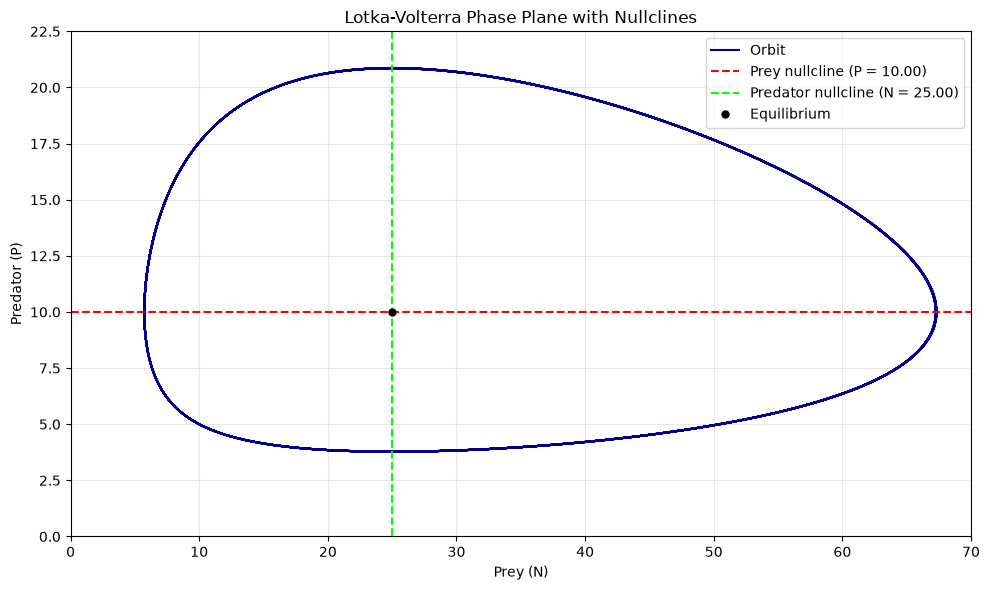

In [ ]:
# finding nullclines and equilibrium

# N* = m/b, P* = r/c
N_star = m / b
P_star = r / c

print(f"Equilibrium point: Prey = {N_star:.2f}, Predator = {P_star:.2f}")

# phase plane with nullclines
plt.figure(figsize=(10, 6))

# the orbit
plt.plot(prey_sol, pred_sol, color='darkblue', linewidth=1.5, label='Orbit')

# prey nullcline
plt.axhline(y=P_star, color='red', linestyle='--', linewidth=1.5, 
            label=f'Prey nullcline (P = {P_star:.2f})')

# predator nullcline
plt.axvline(x=N_star, color='lime', linestyle='--', linewidth=1.5,
            label=f'Predator nullcline (N = {N_star:.2f})')

# equilibrium point
plt.plot(N_star, P_star, 'ko', markersize=5, label='Equilibrium')

plt.xlabel('Prey (N)')
plt.ylabel('Predator (P)')
plt.title('Lotka-Volterra Phase Plane with Nullclines')
plt.legend(loc='upper right')
plt.xlim(0,70)
plt.ylim(0,22.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As you can see graphically from the phase plane, when the orbit crosses the nullcline, the rate of change of the corresponding population is zero. If this rate changes sign when the orbit crosses, then the population has reached a local minimum or maximum.

For example, when the orbit crosses the predator nullcline at the bottom of the phase plane trajectory, we have:

$$
\frac{dP}{dt} = 0
$$

At this point, it is visibly clear that the predator population has reached a local minimum. Before this point, we see the predator population is decreasing. And after this point, we see the population starts to increase again.

This can also be understood by analysing the slope (tangent) of the orbit with respect to the population (in our case we are looking at the population of the predators):

$$
\frac{\frac{dP}{dt}}{\frac{dN}{dt}} = \frac{dP}{dN} = \frac{P(bN-m)}{N(r-cP)} \tag{2.5}
$$

We note that $P>0$, and also we need to clarify that $(2.5)$ is only valid when $\frac{dN}{dt} \neq 0$ (conversely , $\frac{dN}{dP}$ can be used when $\frac{dP}{dt} \neq 0$)

Where the orbit crosses the nullcline at the bottom point, we have:

$$
\frac{dP}{dt} = P(bN-m) = 0 \Rightarrow \frac{dP}{dN} = 0 \tag{2.6}
$$

Therefore, this orbit has a horizontal tangent at this crossing. From earlier, we understand that the orbit is flowing in the counterclockwise direction, meaning that the orbit moves from $N < \frac{m}{b}$ to $N > \frac{m}{b}$ in the lower section, it follows that

$$
\frac{dP}{dt} < 0 \quad when \quad N < \frac{m}{b} \quad and, \quad \frac{dP}{dt} > 0 \quad when \quad N > \frac{m}{b}
$$

Thus $\frac{dP}{dt}$ changes from negative to positive, showing $P(t)$ has a local minimum, since to the left of the intersection point $\frac{m}{b}$, $\frac{dP}{dt}$ is negative, and to the right of $\frac{m}{b}$, the sign of the rate of change flips and becomes positive, indicated by $\frac{dP}{dt}$.

---------

Now, I want to explore what happens when we have the same parameters, but different starting population numbers! Let's write some code, and then break down what we discover.

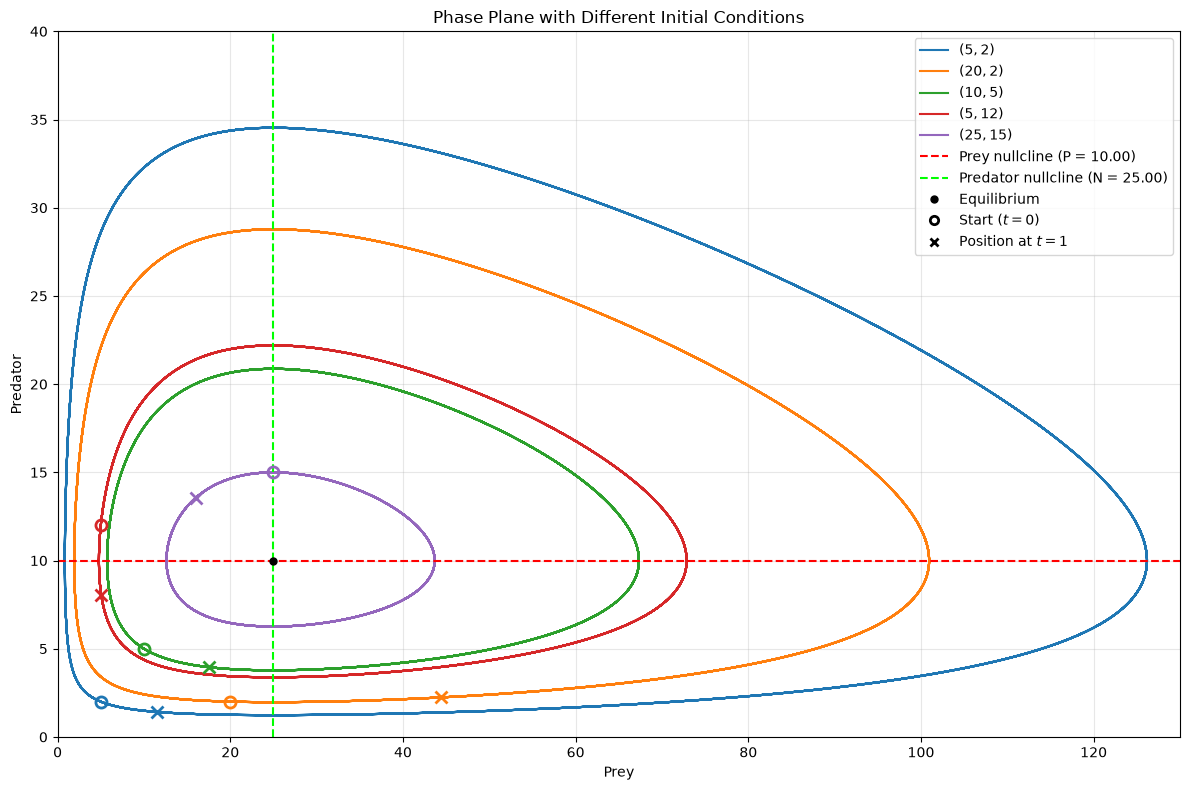

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


def solve_lv(r, c, b, m, prey0, pred0, t_max=100, num_points=10000):
    t = np.linspace(0, t_max, num_points)
    y0 = [prey0, pred0]
    sol = odeint(LV, y0, t, args=(r, c, b, m))
    return t, sol[:, 0], sol[:, 1]

def plot_multiple_trajectories(r ,c ,b ,m , initial_conditions, t_max=100, marker_time=20, num_points=10000):
    plt.figure(figsize=(12, 8))

    N_star = m / b
    P_star = r / c

    for prey0, pred0, label, colour in initial_conditions:
        t, prey_sol, pred_sol = solve_lv(
            r, c, b, m, prey0, pred0, t_max, num_points
        )

        plt.plot(
            prey_sol,
            pred_sol,
            color=colour,
            linewidth=1.5,
            label=label
        )

        mark_index = np.argmin(np.abs(t - marker_time))

        # start and position at the selected time
        plt.plot(
            prey_sol[0],
            pred_sol[0],
            marker='o',
            markerfacecolor='none',
            markeredgecolor=colour,
            markeredgewidth=2,
            markersize=8,
            zorder=5
        )

        plt.plot(
            prey_sol[mark_index],
            pred_sol[mark_index],
            marker='x',
            color=colour,
            markeredgewidth=2,
            markersize=8,
            zorder=5
        )

    # nullclines
    plt.axhline(
        y=P_star,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Prey nullcline (P = {P_star:.2f})'
    )

    plt.axvline(
        x=N_star,
        color='lime',
        linestyle='--',
        linewidth=1.5,
        label=f'Predator nullcline (N = {N_star:.2f})'
    )

    # equilibrium point
    plt.plot(
        N_star,
        P_star,
        'ko',
        markersize=5,
        label='Equilibrium'
    )

    # marker key
    plt.plot(
        [],
        [],
        marker='o',
        linestyle='none',
        markerfacecolor='none',
        markeredgecolor='black',
        markeredgewidth=2,
        label='Start ($t=0$)'
    )

    plt.plot(
        [],
        [],
        marker='x',
        linestyle='none',
        color='black',
        markeredgewidth=2,
        label=f'Position at $t={marker_time}$'
    )

    plt.xlabel('Prey')
    plt.ylabel('Predator')
    plt.title('Phase Plane with Different Initial Conditions')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 130)
    plt.ylim(0, 40)
    plt.tight_layout()
    plt.show()


r = 1.0
c = 0.1
b = 0.02
m = 0.5

initial_conditions = [
    (5, 2, '$(5, 2)$', 'tab:blue'),
    (20, 2, '$(20, 2)$', 'tab:orange'),
    (10, 5, '$(10, 5)$', 'tab:green'),
    (5, 12, '$(5, 12)$', 'tab:red'),
    (25, 15, '$(25, 15)$', 'tab:purple'),
]      
plot_multiple_trajectories(r, c, b, m, initial_conditions, t_max=100, marker_time=1)

We have generated a plot of multiple orbits on one phase plane, where each orbit is generated by a different initial condition. The green orbit is the same as the one discussed earlier. Now let's compare how varying initial conditions change the orbit, keeping the parameters the same:

| Initial populations | Starting condition | Observed behaviour | Ecological interpretation |
|---|---|---|---|
| Prey = $5$, Predators = $2$ (blue)|Prey and predator both low | We can see that this initial condition creates a relatively wide orbit compared to the other orbits. Of the orbits shown, this orbit has the lowest population minima and the highest population maxima for both species.|Given that the predators start off so low, this adds less risk of death for the prey, experiencing less predation pressure, allowing their population to grow. Thus we see a sharp increase in their population, which gives grounds for the predators' population to grow because there is a larger supply of food for them to grow their population |
| Prey = $20$, Predators = $2$ (orange)|Large numbers of prey, few predators | We see that the maximum and minimum population for both predator and prey is higher and lower respectively than all but one orbit (blue). The initial condition for predators is low, we have $\frac{cNP}{rN}=\frac{cP}{r}=\frac{0.1\times2}{1}=0.2$ which shows that the predation level removes $20\%$ of the prey growth term, $20 * 0.2 = 4$ which means that initially the population of prey is increasing at a rate of $20-4=16$ per unit of time.| We start with far less predators than we do with prey, this will give the prey less risk of death since they have a low starting predation pressure. However, this predation pressure is the same as in blue, even though there are more starting prey. This is because the predation rate per prey individual is the same, it is $0.2$ per unit of time for both the blue and orange orbits at $t=0$. |
| Prey = $10$, Predators = $5$ (green)|Both start below equilibrium number| We can see that this orbit is tighter compared to the previous 2 orbits we have examined. | Because the observed orbit is tighter, both populations fluctuate over smaller ranges compared to the blue and orange orbits, they still oscillate but they don't settle towards an equilibrium. |
| Prey = $5$, Predators = $12$ (red)|Few prey but larger population of predators | This orbit is similar to the green orbit, The number of predators is initially decreasing as $\frac{dP}{dt} < 0$| Since the prey population starts below $\frac{m}{b} = 25$, we see the predator population sharply decline as they don't have enough food to sustain their population. The prey population also initially decreases because predators eat prey faster than the prey population can grow.|
| Prey = $25$, Predators = $15$ (purple)|Prey starts at its equilibrium number, where as predators start above their equilibrium value| We observe that this orbit is the tightest of all the other orbits we have discussed. The starting point sits on the predator nullcline, which indicates at the starting point, predators have zero instantaneous growth, where they decrease afterwards. | With these starting conditions, the predator population is at its maximum - signifying that the population size will begin to decrease. The decrease in predators will eventually decrease the predation level, meaning the prey population will begin to grow at $P<10$.|

We have discussed the differences, now we should talk about the similarities each orbit has. We can easily see that the nullclines, and furthermore the coexistence equilibrium, are the same for every orbit. This is because we only changed the starting conditions (starting population) for each orbit, the parameters $r$, $c$, $m$, and $b$ remain unchanged, i.e $\frac{r}{c}$ and $\frac{m}{b}$ are constant. Consequently the local minima and maxima occur on the same nullclines, but at different points along them. It is also important to note that from observing the plot, the orbits remain distinct and do not converge to any point over the simulated time interval.

----

We can further visualise the model more generally by implementing something called a direction field (also known as a vector field), which shows the direction of change at points in the phase plane. This is an important plot to make, since we can see the behaviour of the model on the plotted region, making it easier to identify patterns. Let us write some code for this below and generate a plot.

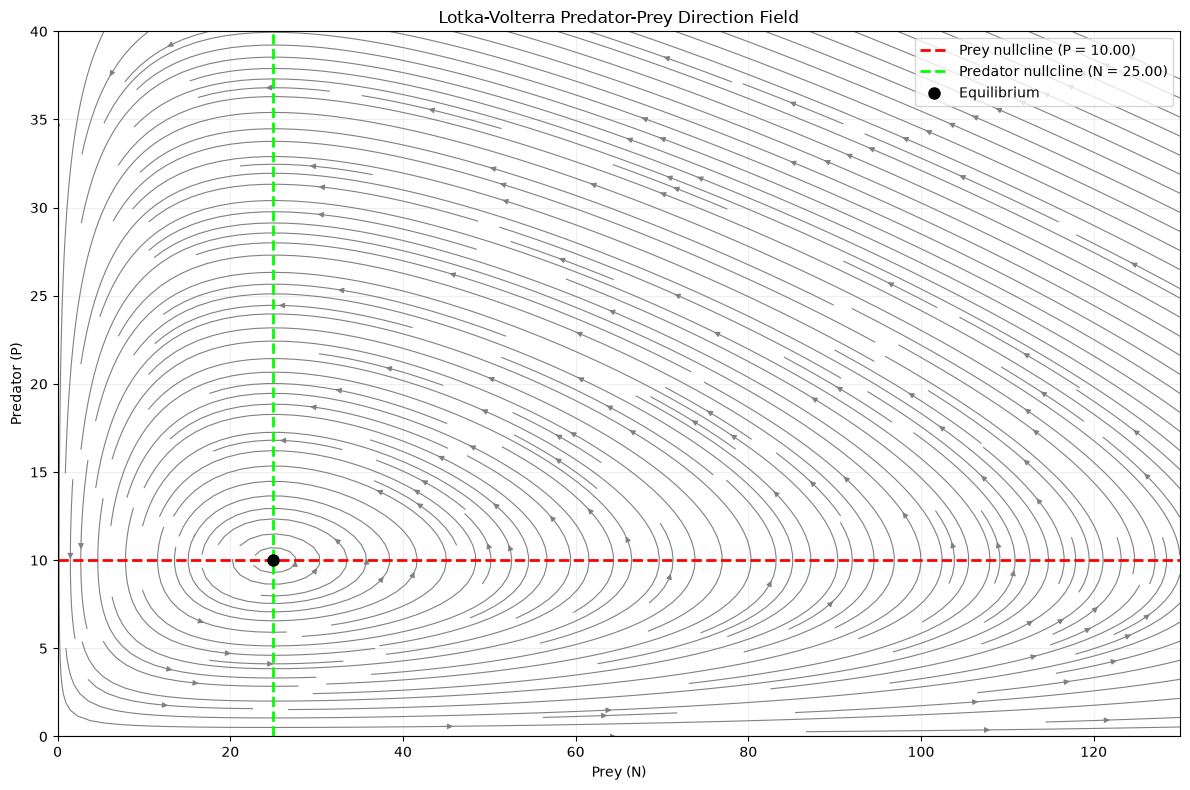

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# equilibrium points
N_star = m / b   
P_star = r / c  

# flow function for the vector field
def LV_flow(prey, pred, r, c, b, m):
    dprey = r * prey - c * prey * pred
    dpred = b * prey * pred - m * pred
    return dprey, dpred

# create grid for streamlines
prey_grid = np.linspace(0, 130, 1000)
pred_grid = np.linspace(0, 40, 1000)
P_grid, C_grid = np.meshgrid(prey_grid, pred_grid)

# compute direction
dP, dC = LV_flow(P_grid, C_grid, r, c, b, m)

# plot
fig, ax = plt.subplots(figsize=(12, 8))

# streamlines
ax.streamplot(P_grid, C_grid, dP, dC, 
              color='gray', 
              linewidth=0.8,
              density=2.5,
              arrowsize=0.8)

# nullclines
ax.axhline(y=P_star, color='red', linestyle='--', linewidth=2,
           label=f'Prey nullcline (P = {P_star:.2f})')
ax.axvline(x=N_star, color='lime', linestyle='--', linewidth=2,
           label=f'Predator nullcline (N = {N_star:.2f})')

# equilibrium
ax.plot(N_star, P_star, 'ko', markersize=8, label='Equilibrium')

# labels and formatting
ax.set_xlabel('Prey (N)')
ax.set_ylabel('Predator (P)')
ax.set_title('Lotka-Volterra Predator-Prey Direction Field')
ax.set_xlim(0, 130)
ax.set_ylim(0, 40)
ax.grid(True, alpha=0.2)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


On the direction field plot, the arrows signify the instantaneous direction of change. We can see the counter-clockwise nature of the cyclic orbit from the direction the vectors (arrows) are pointing. Away from equilibrium, the vectors are perpendicular to the corresponding positive nullcline. On the prey nullcline, we have $\frac{dN}{dt} = 0$, so the vectors point vertically and on the predator nullcline, we have $\frac{dP}{dt} = 0$, meaning the vectors point horizontally. Further more, the plot suggests that the orbits are orbiting around the coexistence equilibrium, never converging to it. You see, we used this visual representation of the model to get a more generalised look at how the model behaves, and seeing the patters that emerge. 

For an initial condition where both predator and prey populations are positive and away from the coexistence equilibrium, you can imagine it as a particle on top of water with a current (directional vectors). When this particle starts to move, it follows the trajectory of the current. And in this case, it will move in a cyclic orbit and return back to the same point it was placed on. If this particle was placed directly on the coexistence equilibrium, it would stay where it is and not move.

----

We can express the population of predators and prey on a time series graph. It is another tool which allows us to interpret the model in a different way. Let's write some code for it using the same parameters and initial conditions from the first plot in the notebook!

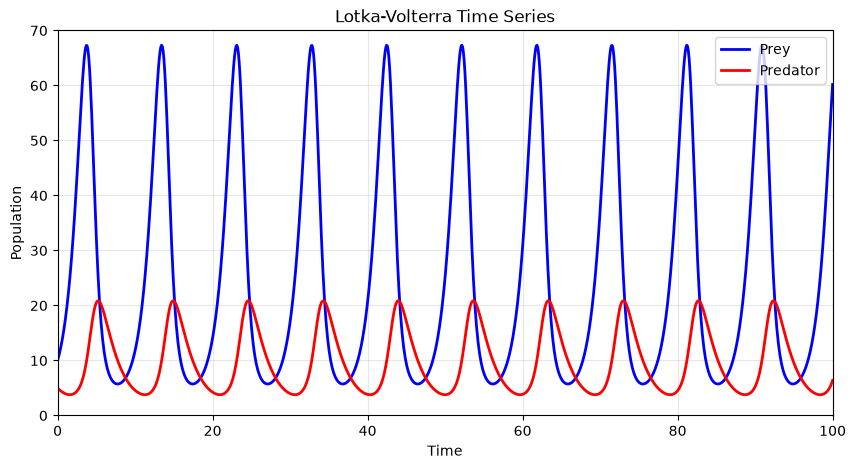

In [6]:
# plotting time series

plt.figure(figsize=(22, 5))

plt.subplot(1, 2, 1)
plt.plot(t, prey_sol, label='Prey', color='blue', linewidth=2)
plt.plot(t, pred_sol, label='Predator', color='red', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra Time Series')
plt.legend(loc='upper right')
plt.xlim(0,100)
plt.ylim(0,70)
plt.grid(True, alpha=0.3)
plt.show()

Here we can see the cyclic nature of the population for predators and prey. But we notice that there is an offset between predators and prey, their peaks happen at different units of time. This is called lag. In ecological terms, This lag is experienced because: decreased predators means predation is lower -> less predation means less threat to prey so prey population increases -> more prey means more food for predators meaning the predators can have more offspring, increasing the predators -> more predators means higher predation, decreases population of prey -> less prey means less food for predators to sustain their population, predator population decreases. The predator peak happens after the prey peak, predators continue increasing after prey start declining because enough prey still remain to support the predator growth. Predators start declining when the population for prey fall below $N=\frac{m}{b}$.

----

Moving on from this, let us explore changing one parameter, namely $r$ - prey growth rate, while keeping the initial conditions and other parameters constant.

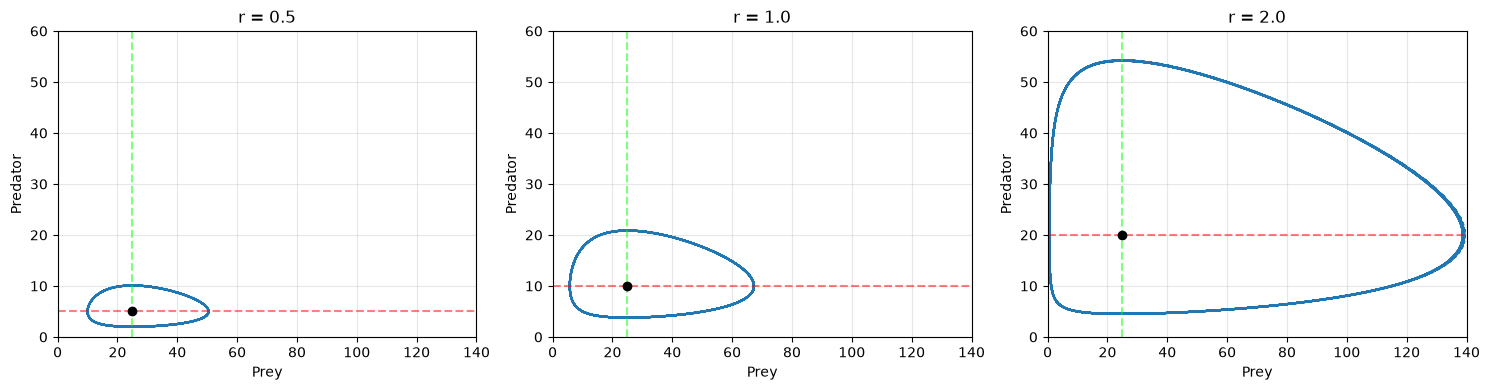

In [ ]:
r_values = [0.5, 1.0, 2.0]
plt.figure(figsize=(15, 4))

for i, r_val in enumerate(r_values):
    sol = odeint(LV, y0, t, args=(r_val, c, b, m))
    plt.subplot(1, 3, i+1)
    plt.plot(sol[:, 0], sol[:, 1], linewidth=1.5)
    plt.axhline(y=r_val/c, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=m/b, color='lime', linestyle='--', alpha=0.5)
    plt.plot(m/b, r_val/c, 'ko', markersize=6)
    plt.xlabel('Prey')
    plt.ylabel('Predator')
    plt.title(f'r = {r_val}')
    plt.xlim(0, 140)
    plt.ylim(0, 60)
    plt.grid(True, alpha=0.3)
    

plt.tight_layout()
plt.show()


It is clear that the prey nullcline moves upwards as the value of r increases. This makes sense since the nullcline for prey is given by $P=\frac{r}{c}$, so if r increases, the nullcline also increases. And naturally the coexistence equilibrium shifts upwards as $\frac{r}{c}$ increases and $\frac{m}{b}$ stays fixed.

Increasing $r$ means that prey grows faster in the absence of predators, meaning that the predators have a larger food source and a larger predator population is required to balance the faster prey growth at equilibrium. The prey abundance to balance predator mortality remains as $\frac{m}{b}$ because we only change $r$.